# 4.2 Hot-Spot Detection and Local Clustering

**Part:** 4 — Spatial Cluster Analysis (Chapter 4.2 of 8)

**Dataset:** `diabetes_northeast.shp` (217 counties)

**Focus:** Getis-Ord Gi and Gi* hot-spot analysis, its relationship to Part 2's Local Moran's I, and robustness across weights and settings

**Library:** `spatialstats.cluster`, `spatialstats.esda` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Global Tests, Revisited](#3.-Global-Tests,-Revisited)
4.. [Getis-Ord Gi and Gi*](#4.-Getis-Ord-Gi-and-Gi*)
   - 4.1 [Gi vs. Gi*: including or excluding the area itself](#4.1-Gi-vs.-Gi*:-including-or-excluding-the-area-itself)
   - 4.2 [Analytic vs. permutation inference, and the FDR resolution limit again](#4.2-Analytic-vs.-permutation-inference,-and-the-FDR-resolution-limit-again)
5.. [Gi* vs. Local Moran: Clusters vs. Outliers](#5.-Gi*-vs.-Local-Moran:-Clusters-vs.-Outliers)
6.. [Local Geary and Multivariate Clustering](#6.-Local-Geary-and-Multivariate-Clustering)
7.. [Robustness Across Weights and Settings](#7.-Robustness-Across-Weights-and-Settings)
8.. [Summary and Conclusions](#8.-Summary-and-Conclusions)
9.. [Resources](#9.-Resources)

***
## 1. Overview

Part 2 built Local Moran's I as the local decomposition of a *product* (each county's value times its
neighbours' values). Getis-Ord Gi and Gi* build a different local statistic — a *ratio* of the neighbourhood's
sum to the region's total — that answers a subtly different question, with its own inference machinery and its
own version of Part 2's FDR resolution-limit trap.

| Step | What we do |
|------|------------|
| Global review | `GeneralG`, `Join_Counts` — "is there" clustering, before asking "where" |
| Gi / Gi* | Full definition, and the practical difference between excluding and including the area itself |
| Inference | Analytic (Ord & Getis 1995) vs. conditional-permutation p-values, and Part 2's resolution-limit story, replayed for Gi* |
| Gi* vs. LISA | Side-by-side maps and a quantified agreement table — clusters and outliers are not the same thing |
| Local Geary | A companion local statistic, and the standard multivariate-LISA workaround |
| Robustness | Weights, permutations, and FDR on/off, summarised with `flag_stability` |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen, KNN, DistanceBand
from spatialstats.esda import GeneralG, Join_Counts, Moran_Local, Geary_Local
from spatialstats.cluster import getis_ord_gi, local_moran_clusters, agreement_matrix, flag_stability

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_northeast.shp")
w = Queen(counties)
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Global Tests, Revisited

Before asking *where*, Part 2 already established whether clustering exists at all: `GeneralG` tests for
high-value clustering specifically, `Join_Counts` for the categorical analogue.

In [2]:
gg = GeneralG(counties["Dia_pct"], w, permutations=999, seed=1)
above_median = (counties["Dia_pct"] > counties["Dia_pct"].median()).astype(int)
jc = Join_Counts(above_median, w, permutations=999, seed=1)
print(f"General G: {gg.G:.5f}, p={gg.p_value:.3f}")
print(f"Join counts BB: {jc['BB']:.0f}, p={jc['p_BB']:.3f}")

General G: 0.00465, p=0.007
Join counts BB: 156, p=0.022


Both confirm (as Part 2 already found) that high-value clustering exists globally. Everything in this chapter
now asks *where* — a genuinely separate question that a significant global test cannot answer by itself.

***
## 4. Getis-Ord Gi and Gi*

$$
G_i^* = \frac{\sum_j w_{ij}\, y_j}{\sum_j y_j}, \qquad j \text{ ranges over } i\text{'s neighbourhood}
\textbf{ including } i.
$$

$G_i^*$ compares the sum of values in $i$'s neighbourhood against what an even spread of the total would give;
a large positive standardised score is a **hot spot** (high values clustered together), a large negative one a
**cold spot**. Unlike Local Moran, Gi*/Gi finds clusters of *values*, not outliers — a single unusually high
county surrounded by low ones does not register as a Gi* hot spot the way it would as an HL LISA outlier.

### 4.1 Gi vs. Gi*: including or excluding the area itself

`star=True` (Gi*) includes $i$ in its own neighbourhood sum; `star=False` (Gi) excludes it, testing only
whether $i$'s *neighbours* (not $i$ itself) sum unusually high.

In [3]:
gi_star = getis_ord_gi(counties["Dia_pct"], w, star=True, inference="analytic", correction="fdr")
gi_plain = getis_ord_gi(counties["Dia_pct"], w, star=False, inference="analytic", correction="fdr")
print(f"Gi*  (self included): {gi_star.hot.sum()} hot spots, {gi_star.cold.sum()} cold spots")
print(f"Gi   (self excluded): {gi_plain.hot.sum()} hot spots, {gi_plain.cold.sum()} cold spots")

Gi*  (self included): 7 hot spots, 3 cold spots
Gi   (self excluded): 2 hot spots, 0 cold spots


Gi* finds far more (7 hot + 3 cold vs. Gi's 2 hot + 0 cold): including the area's own (typically extreme) value
in the sum it is testing makes hot/cold status easier to reach, since an area contributes to confirming its own
classification. **Gi* is the standard choice** in most software and most published applications; Gi is useful
specifically when the question is "does this area's *neighbourhood*, on its own, look unusual" — e.g. for
identifying a location worth investigating precisely because it differs from its surroundings.

### 4.2 Analytic vs. permutation inference, and the FDR resolution limit again

`inference='analytic'` uses the Ord & Getis (1995) normal approximation; `inference='permutation'` uses
conditional permutation (hold $y_i$ fixed, resample its neighbours). Both p-values are always computed and
returned; `inference=` only selects which one drives the significance labelling.

In [4]:
gi_perm = getis_ord_gi(counties["Dia_pct"], w, star=True, inference="permutation",
                       permutations=999, correction="fdr", seed=1)
print(f"Gi* (permutation p, FDR, 999 perms): {gi_perm.hot.sum()} hot, {gi_perm.cold.sum()} cold")

Gi* (permutation p, FDR, 999 perms): 0 hot, 0 cold


/tmp/ipykernel_1549675/3964052924.py:1: UserWarning: With 999 permutations the smallest attainable p-value is 0.002, so at least 9 of 217 areas would have to sit at that minimum to survive FDR at alpha=0.05; few or no clusters may be detected. Use more permutations (>= 8680) or inference='analytic' (Gi*).
  gi_perm = getis_ord_gi(counties["Dia_pct"], w, star=True, inference="permutation",


**Zero, flagged with a warning** — the exact same failure mode Part 2, Chapter 2.5 found for `Moran_Local`:
with 999 permutations the smallest attainable p-value is $2/(m{+}1)=0.002$, and FDR correction across 217
simultaneous tests needs more resolution than that to flag anything at all. The library's own warning states
the estimated minimum permutation count directly; the **analytic** p-value (Section 4, no permutation floor)
is the practical default for Gi*/Gi precisely to sidestep this — which is why `inference='analytic'` is this
function's own default, unlike `Moran_Local`'s default of an under-powered permutation-based FDR test.

In [5]:
import warnings as _w
with _w.catch_warnings(record=True) as caught:
    _w.simplefilter("always")
    getis_ord_gi(counties["Dia_pct"], w, star=True, inference="permutation",
                permutations=999, correction="fdr", seed=1)
    print(str(caught[0].message))

With 999 permutations the smallest attainable p-value is 0.002, so at least 9 of 217 areas would have to sit at that minimum to survive FDR at alpha=0.05; few or no clusters may be detected. Use more permutations (>= 8680) or inference='analytic' (Gi*).


***
## 5. Gi* vs. Local Moran: Clusters vs. Outliers

Both methods look for "where", but they are built to find different things: Gi*/Gi finds clusters of
**values** (high near high); Local Moran additionally flags spatial **outliers** (a high value surrounded by
low, or vice versa). Part 2, Chapter 2.3's Bronx County — an HL outlier, high prevalence surrounded by lower
neighbours — is exactly the kind of point Gi* is not built to find but Local Moran is.

In [6]:
lisa = local_moran_clusters(counties["Dia_pct"], w, permutations=999, seed=1, correction="none")
print("LISA (uncorrected, p<=0.05):")
print(pd.Series(lisa.labels).value_counts())

LISA (uncorrected, p<=0.05):
Not significant    187
HH                  13
LL                  11
LH                   4
HL                   2
Name: count, dtype: int64


In [7]:
masks = {
    "Gi* hot": gi_star.hot, "Gi* cold": gi_star.cold,
    "LISA HH": lisa.labels == "HH", "LISA LL": lisa.labels == "LL",
}
agreement_matrix(masks).round(3)

,Gi* hot,Gi* cold,LISA HH,LISA LL
Gi* hot,1.000,0.000,0.538,0.000
Gi* cold,0.000,1.000,0.000,0.273
LISA HH,0.538,0.000,1.000,0.000
LISA LL,0.000,0.273,0.000,1.000


Gi* hot spots and LISA's HH counties overlap substantially (Jaccard 0.54) but are **not identical** — every
county flagged HH is "a high value near high values", which is close to but not the same test as "the
neighbourhood sum is unusually high". The LL/cold overlap is weaker still (0.27). Neither method is "more
correct"; they are two related but distinct definitions of the same intuitive idea, and reporting only one
without checking the other risks presenting a single arbitrary choice as if it were the only possible answer.

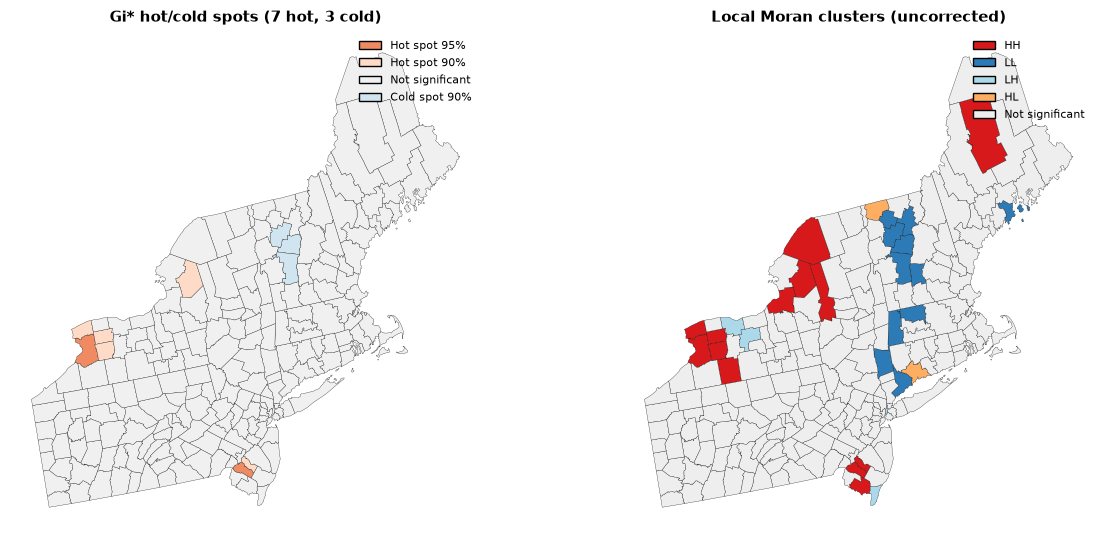

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
gi_star.plot(gdf=counties, ax=axes[0])
axes[0].set_title(f"Gi* hot/cold spots ({gi_star.hot.sum()} hot, {gi_star.cold.sum()} cold)")
lisa.plot(gdf=counties, ax=axes[1])
axes[1].set_title("Local Moran clusters (uncorrected)")
plt.tight_layout()
plt.show()

***
## 6. Local Geary and Multivariate Clustering

`Geary_Local` is the pointwise decomposition of Part 2's Geary's C: it measures local *dissimilarity* between
neighbours directly, rather than a product of centred values, and — being a sum of squared differences — is
sensitive to *any* kind of local contrast, not specifically the four HH/LL/HL/LH categories.

In [9]:
local_geary = Geary_Local(counties["Dia_pct"], w, permutations=999, seed=1, fdr=False)
sig_geary = local_geary.p_sim <= 0.05
print(f"Local Geary significant (uncorrected, p<=0.05): {sig_geary.sum()} of {len(counties)}")

Local Geary significant (uncorrected, p<=0.05): 4 of 217


Only 4 counties — considerably more conservative than LISA's 30 (Section 5) or Gi*'s 10, because local Geary's
squared-difference statistic has higher variance and less power at moderate sample sizes than the product-based
alternatives.

**Multivariate clustering** is not natively supported by any local statistic here (each takes one variable at a
time); the standard workaround is to standardise several variables, reduce them to their first principal
component, and run Local Moran on that composite:

In [10]:
from sklearn.decomposition import PCA

health_vars = counties[["Dia_pct", "Obesity", "PhysInact", "SVI"]].to_numpy()
health_std = (health_vars - health_vars.mean(axis=0)) / health_vars.std(axis=0)
pc1 = PCA(n_components=1).fit_transform(health_std).ravel()

lisa_multivariate = Moran_Local(pc1, w, permutations=999, seed=1, fdr=False)
print(f"Multivariate (PC1 of 4 health variables) LISA: {(lisa_multivariate.labels != 'NS').sum()} significant")
print(pd.Series(lisa_multivariate.labels[lisa_multivariate.labels != "NS"]).value_counts())

Multivariate (PC1 of 4 health variables) LISA: 23 significant
HH    11
LL    10
LH     2
Name: count, dtype: int64


23 significant counties on the composite health-burden axis — a genuinely different, and arguably more
complete, picture than any single variable's LISA map alone, at the cost of losing the direct interpretability
of "this is about diabetes specifically". Treat this as a documented 🟡 workaround, not a first-class
multivariate method: the PCA step discards information, and the composite's meaning depends on which variables
were chosen to build it.

***
## 7. Robustness Across Weights and Settings

As in Part 2, Chapter 2.6: does the Gi* hot-spot map survive a change of weights definition?

In [11]:
weight_defs = {"Queen": Queen(counties), "KNN(6)": KNN(counties, k=6),
              "DistanceBand(100km)": DistanceBand(counties, threshold=100_000, binary=True)}
masks = {}
for name, w_def in weight_defs.items():
    res = getis_ord_gi(counties["Dia_pct"], w_def, star=True, inference="analytic", correction="fdr")
    masks[name] = res.hot | res.cold
    print(f"{name:22s}: {masks[name].sum()} flagged (hot or cold)")

stability = flag_stability(list(masks.values()))
print(f"\nrobust (flagged under all 3 definitions): {int((stability == 1.0).sum())}")
print(f"flagged under exactly 1 of 3: {int(np.sum((stability > 0) & (stability < 1.0)))}")

Queen                 : 10 flagged (hot or cold)
KNN(6)                : 26 flagged (hot or cold)


DistanceBand(100km)   : 46 flagged (hot or cold)

robust (flagged under all 3 definitions): 7
flagged under exactly 1 of 3: 47


The exact same pattern as Part 2's LISA robustness check: denser weight definitions flag more counties
(DistanceBand's 46 vs. Queen's 10), and only 7 counties are robust across all three. The lesson repeats because
it is general, not specific to Local Moran: **any local statistic's flagged set is conditional on the weights
definition**, and a stability check like this one should accompany any hot-spot map presented as a finding.

***
## 8. Summary and Conclusions

This chapter gave Getis-Ord Gi/Gi* the same full, calibrated treatment Part 2 gave Local Moran's I.

### What we did

1. Reviewed the global tests (`GeneralG`, `Join_Counts`) that confirm clustering exists before asking where.
2. Compared Gi* (self included, 7 hot + 3 cold) against Gi (self excluded, 2 hot + 0 cold) — Gi* is the more
   commonly used, more powerful default.
3. Replayed Part 2's FDR-resolution-limit trap for Gi*: permutation inference plus FDR at 999 permutations
   flags zero counties, exactly as it did for `Moran_Local` — and confirmed this is why analytic inference is
   this function's own default.
4. Quantified Gi*-vs-LISA agreement directly (Jaccard 0.54 for hot/HH, 0.27 for cold/LL) — related but not
   identical statistics.
5. Ran Local Geary (far more conservative: 4 significant vs. LISA's 30) and the standard PCA-based multivariate
   LISA workaround (23 significant on a composite health-burden axis).
6. Repeated Part 2's weights-sensitivity check for Gi*: only 7 of up to 46 ever-flagged counties are robust
   across three weight definitions.

### Practical takeaways

- Default to Gi* with analytic inference unless there is a specific reason to exclude the area itself or to use
  permutation p-values with a permutation count large enough for FDR to have room to operate.
- Gi*/Gi and Local Moran answer related but distinct questions; report both, or at minimum state which one was
  used and why, rather than treating "hot spot" as a single unambiguous concept.
- The multivariate-LISA-via-PCA workaround is useful but lossy; document the variables and the PCA step
  explicitly whenever it is used.

### Next steps

**Chapter 4.3 (Density-Based Point Clustering)** leaves areal data behind and returns to Part 1's raw crime
event locations, this time asking where events are *densely packed* rather than whether the pattern departs
from CSR.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Getis, A. & Ord, J. K. (1996). Local spatial statistics: an overview. In *Spatial Analysis: Modelling in a GIS Environment*. | Overview of the Gi/Gi* family alongside Local Moran |
| Ord, J. K. & Getis, A. (1995). Local spatial autocorrelation statistics: distributional issues and an application. *Geographical Analysis*, 27, 286–306. | Origin of the analytic standardised-score inference used by default |

### Key papers

| Paper | Contribution |
|---|---|
| Getis, A. & Ord, J. K. (1992). The analysis of spatial association by use of distance statistics. *Geographical Analysis*, 24, 189–206. | Original Gi/Gi* statistic |
| Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*, 27, 93–115. | Local Geary, alongside Local Moran |

### In this library

| Object | Role |
|---|---|
| `spatialstats.cluster.getis_ord_gi` | Gi/Gi* hot-spot analysis, with analytic and permutation inference |
| `spatialstats.cluster.local_moran_clusters` | Conditional-permutation LISA, reused from Part 2's `esda` |
| `spatialstats.esda.Geary_Local` | Local Geary |
| `spatialstats.cluster.agreement_matrix`, `flag_stability` | Cross-method and cross-setting robustness, used throughout this chapter |
| Chapter 4.6 | Full multi-method comparison panel, extending Section 5's two-method comparison |